In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [31]:
df = pd.read_csv("superstore_3_csv.csv")
print(df)

     Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0         1  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
1         2  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
2         3  CA-2016-138688   6/12/2016   6/16/2016    Second Class   
3         4  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
4         5  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
..      ...             ...         ...         ...             ...   
145     146  CA-2015-110744    9/7/2015   9/12/2015  Standard Class   
146     147  CA-2014-110072  10/22/2014  10/28/2014  Standard Class   
147     148  CA-2016-114489   12/5/2016   12/9/2016  Standard Class   
148     149  CA-2016-114489   12/5/2016   12/9/2016  Standard Class   
149     150  CA-2016-114489   12/5/2016   12/9/2016  Standard Class   

    Customer ID      Customer Name      Segment        Country  \
0      CG-12520        Claire Gute     consumer  United States   
1      CG-12520

In [5]:
print(df.head())


   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   consumer  United States        HENDERSON  ...   
1      Claire Gute   CONSUMER  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      LOS ANGELES  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [6]:
print(df.shape)

(150, 21)


In [7]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')


In [8]:
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [9]:
print(df.describe())

           Row ID   Postal Code        Sales    Quantity    Discount  \
count  150.000000    150.000000   150.000000  150.000000  150.000000   
mean    75.500000  58557.293333   205.101318    3.986667    0.155133   
std     43.445368  28716.649935   396.966111    2.449453    0.207655   
min      1.000000  10009.000000     1.248000    1.000000    0.000000   
25%     38.250000  33883.500000    20.002500    2.000000    0.000000   
50%     75.500000  58181.500000    68.425000    3.000000    0.150000   
75%    112.750000  90004.000000   198.468000    6.000000    0.200000   
max    150.000000  98103.000000  3083.430000   14.000000    0.800000   

            Profit  
count   150.000000  
mean      6.964154  
std     161.807482  
min   -1665.052200  
25%       2.169900  
50%       9.062100  
75%      22.522100  
max     585.552000  


In [13]:
cs = df.groupby("Category")["Sales"].sum()
print(cs)

Category
FURNITURE          5877.9172
Furniture          9278.2925
OFFICE SUPPLIES     593.0620
Office Supplies    4963.8200
TECHNOLOGY         3166.5140
Technology         1583.6900
furniture           261.9600
office supplies    1892.2760
technology         3147.6660
Name: Sales, dtype: float64


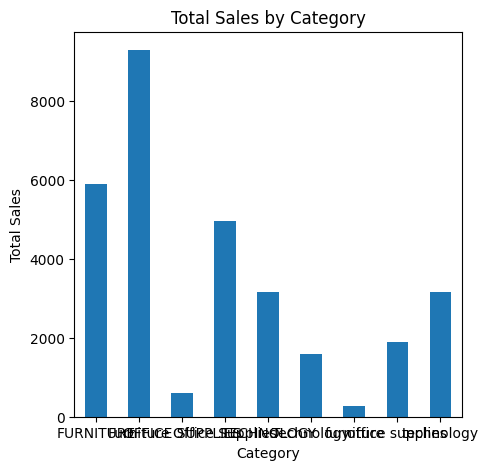

In [16]:
plt.figure(figsize=(5, 5))
cs.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)

plt.show()

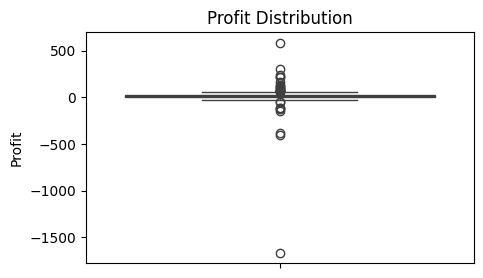

In [20]:
plt.figure(figsize=(5, 3))
sns.boxplot(y=df["Profit"])
plt.title("Profit Distribution")
plt.ylabel("Profit")
plt.show()

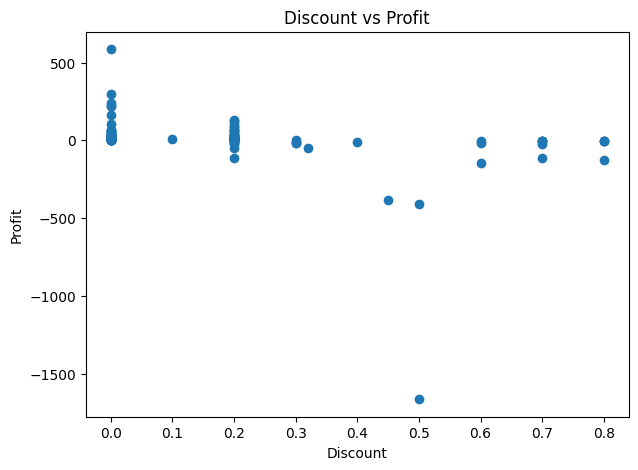

In [23]:
plt.figure(figsize=(7, 5))
plt.scatter(df["Discount"], df["Profit"])
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

In [24]:
numerical_columns = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit"
]
co_matrix = df[numerical_columns].corr()

print("\nCorrelation Matrix:")
print(co_matrix)


Correlation Matrix:
             Sales  Quantity  Discount    Profit
Sales     1.000000  0.307215  0.053646 -0.323908
Quantity  0.307215  1.000000 -0.020580 -0.026155
Discount  0.053646 -0.020580  1.000000 -0.301511
Profit   -0.323908 -0.026155 -0.301511  1.000000


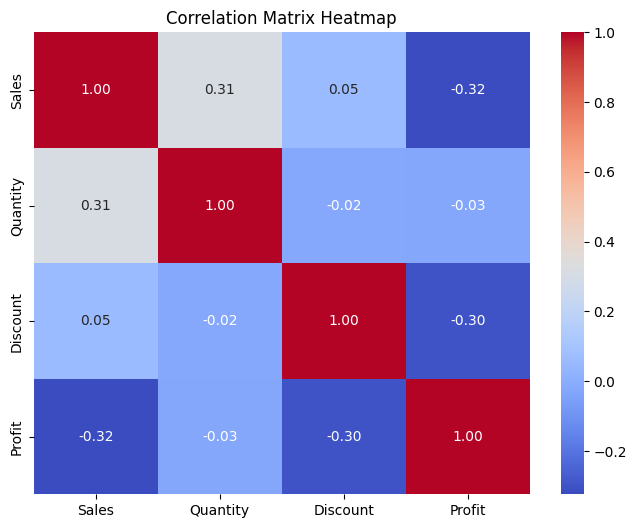

In [26]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    co_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix Heatmap")
plt.show()


In [30]:
category_profit = df.groupby("Category")["Profit"].sum()
print("\nTotal Profit for Each Category:")
print(category_profit)
highest_profit = category_profit.idxmax()
highest_profit = category_profit.max()
print("\nCategory with Highest Total Profit:")
print(highest_profit)
print("Highest Total Profit:")
print(highest_profit)


Total Profit for Each Category:
Category
FURNITURE            33.8991
Furniture         -1358.3410
OFFICE SUPPLIES     160.2718
Office Supplies     880.5199
TECHNOLOGY          396.2234
Technology          271.0322
furniture            41.9136
office supplies     330.6316
technology          288.4725
Name: Profit, dtype: float64

Category with Highest Total Profit:
880.5199
Highest Total Profit:
880.5199
